Create paths and retrieve data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [16]:
factors = pd.read_excel("project Factors_2026.xlsx")
stocks = pd.read_excel("project Stocks_2026.xlsx")
funds = pd.read_excel("project Funds_2026.xlsx")



1.)

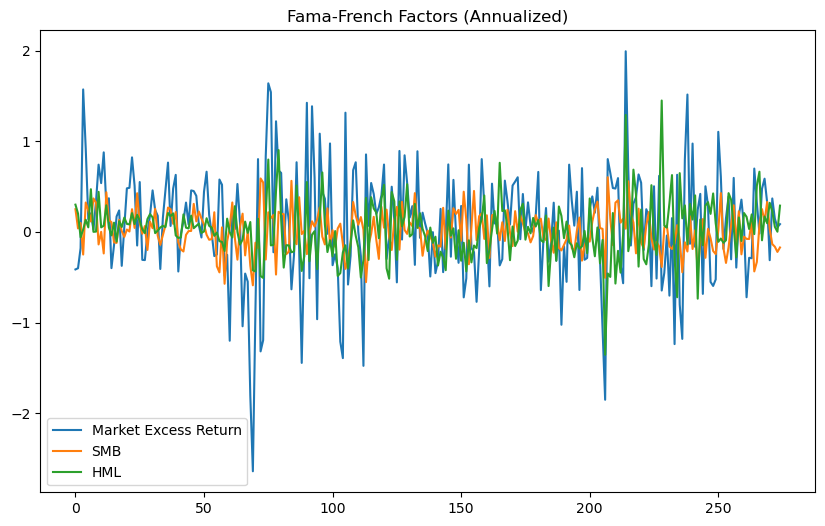

Average factor returns:
rm_rf     0.084113
smb_vw    0.008662
hml_vw    0.021844
dtype: float64

Variance-Covariance matrix:
           rm_rf    smb_vw    hml_vw
rm_rf   0.384355  0.007809  0.062876
smb_vw  0.007809  0.047823 -0.005452
hml_vw  0.062876 -0.005452  0.094322

Average Risk Free Rate:
0.016088727272727275


In [6]:
factors[['rm_rf','smb_vw','hml_vw','rf']] *= 12
stocks.iloc[:,3:] *= 12   


plt.figure(figsize=(10,6))
plt.plot(factors['rm_rf'], label='Market Excess Return')
plt.plot(factors['smb_vw'], label='SMB')
plt.plot(factors['hml_vw'], label='HML')
plt.legend()
plt.title("Fama-French Factors (Annualized)")
plt.show()

print("Average factor returns:")
print(factors[['rm_rf','smb_vw','hml_vw']].mean())

print("\nVariance-Covariance matrix:")
print(factors[['rm_rf','smb_vw','hml_vw']].cov())

print("\nAverage Risk Free Rate:")
print(factors['rf'].mean())


2.)

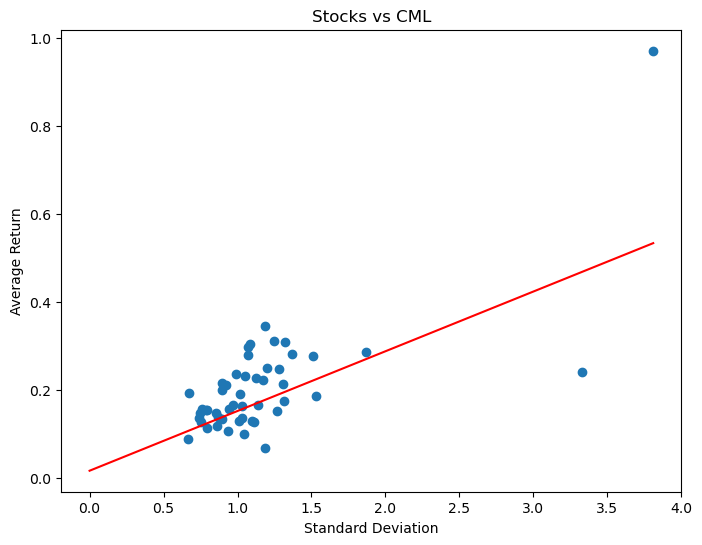

In [7]:
# Medel & STD aktier
stock_means = stocks.iloc[:,3:].mean()
stock_std = stocks.iloc[:,3:].std()

# CML
rf = factors['rf'].mean()
market_mean = factors['rm_rf'].mean() + rf
market_std = factors['rm_rf'].std()

x = np.linspace(0, stock_std.max(), 100)
cml = rf + (market_mean - rf)/market_std * x

# Scatter aktier
plt.figure(figsize=(8,6))
plt.scatter(stock_std, stock_means)
plt.plot(x, cml, color='red')
plt.xlabel("Standard Deviation")
plt.ylabel("Average Return")
plt.title("Stocks vs CML")
plt.show()


3.)

In [8]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

R  = stocks.iloc[:,3:]                  # aktier (annualiserade obs)
rf = factors["rf"]
m  = factors["rm_rf"]
s  = factors["smb_vw"]
h  = factors["hml_vw"]

# samma längd
n = min(len(R), len(factors))
R, rf, m, s, h = R.iloc[:n], rf.iloc[:n], m.iloc[:n], s.iloc[:n], h.iloc[:n]

mu_rf, mu_m, mu_s, mu_h = rf.mean(), m.mean(), s.mean(), h.mean()

rows = []
for col in R.columns:
    y = R[col] - rf

    capm = sm.OLS(y, sm.add_constant(m), missing="drop").fit()
    b_m  = capm.params["rm_rf"]

    ff3 = sm.OLS(y, sm.add_constant(pd.DataFrame({"rm_rf":m, "smb_vw":s, "hml_vw":h})),
                 missing="drop").fit()
    b_m3, b_s3, b_h3 = ff3.params["rm_rf"], ff3.params["smb_vw"], ff3.params["hml_vw"]

    ER_capm = mu_rf + b_m  * mu_m
    ER_ff3  = mu_rf + b_m3 * mu_m + b_s3 * mu_s + b_h3 * mu_h

    rows.append([col, b_m, b_m3, b_s3, b_h3, ER_capm, ER_ff3])

res3 = pd.DataFrame(rows, columns=[
    "Stock","beta_CAPM","betaM_FF3","betaSMB","betaHML","E[R]_CAPM","E[R]_FF3"
]).set_index("Stock")

res3["Diff_FF3_minus_CAPM_pp"] = 100*(res3["E[R]_FF3"] - res3["E[R]_CAPM"])
print(res3.sort_values("Diff_FF3_minus_CAPM_pp", ascending=False).head(15))


                             beta_CAPM  betaM_FF3   betaSMB   betaHML  \
Stock                                                                   
Copperstone Resources AB B    0.350808   0.388900  2.145185 -0.412113   
Bergman & Beving AB B         0.954404   0.902399  1.590383  0.107576   
Avanza Bank Holding AB        0.794548   0.786632  1.660314 -0.168237   
NOTE AB                       0.948141   0.947666  1.312779 -0.191580   
RaySearch Laboratories AB B   0.927772   0.954787  1.341959 -0.338111   
Orron Energy AB               0.948298   0.966140  1.228499 -0.267852   
SEB AB A                      0.941340   0.825600  0.037032  0.695341   
ITAB Shop Concept AB          0.808055   0.872884  1.544753 -0.614950   
Swedbank AB A                 1.043848   0.921244 -0.141603  0.760125   
Bahnhof AB B                  0.215760   0.294106  1.231620 -0.566909   
Ework Group AB                0.653512   0.685954  0.898420 -0.272769   
Saab AB B                     0.684451   0.635095  

4.)

In [15]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

mcap = pd.read_excel("project Stocks_2026.xlsx", sheet_name="Market cap")

# post-2015 => från 2016
mask = stocks["Year"] >= 2016

R = stocks.loc[mask].copy()          # har Year/Month + returns (already *12)
C = mcap.loc[mask].copy()            # Year/Month + caps (inte *12)

stock_cols = stocks.columns[3:]

# bygg portföljreturer med Year/Month så vi kan merge:a exakt
port_rows = []

for yr in sorted(R["Year"].unique()):
    R_y = R[R["Year"] == yr]
    C_y = C[C["Year"] == yr]
    if R_y.empty or C_y.empty:
        continue

    # cap i början av året: jan annars första månad
    C_jan = C_y[C_y["Month"] == 1]
    cap0 = (C_jan.iloc[0] if not C_jan.empty else C_y.iloc[0])[stock_cols].dropna()

    # grupper (1=small ... 5=large)
    ranks = cap0.rank(method="first")
    g = pd.qcut(ranks, 5, labels=[1,2,3,4,5])

    # portföljreturer per månad i året
    for _, row in R_y.iterrows():
        for i in [1,2,3,4,5]:
            members = g.index[g == i]
            port_rows.append({
                "Year": row["Year"],
                "Month": row["Month"],
                "Portfolio": f"S{i}",
                "ret": row[members].mean(skipna=True)
            })

ports = pd.DataFrame(port_rows)

# --- stats mean/std ---
stats4 = ports.groupby("Portfolio")["ret"].agg(["mean","std"])
print("Mean/Std (post-2015):")
print(stats4)

# --- merge faktorer på Year/Month och kör CAPM alpha ---
f = factors.copy()
f["Year"]  = f["year"] if "year" in f.columns else f["Year"]
f["Month"] = f["month"] if "month" in f.columns else f["Month"]

ports = ports.merge(f[["Year","Month","rf","rm_rf"]], on=["Year","Month"], how="inner")
ports["excess"] = ports["ret"] - ports["rf"]

alpha_rows = []
for p in sorted(ports["Portfolio"].unique()):
    dfp = ports[ports["Portfolio"] == p].dropna(subset=["excess","rm_rf"])
    fit = sm.OLS(dfp["excess"], sm.add_constant(dfp["rm_rf"])).fit()
    alpha_rows.append([p, fit.params["const"], fit.tvalues["const"], fit.pvalues["const"]])

alpha_df = pd.DataFrame(alpha_rows, columns=["Portfolio","alpha","t","p"]).set_index("Portfolio")
print("\nCAPM alpha (decimal/år):")
print(alpha_df)

print("\nCAPM alpha (%/år):")
print(100*alpha_df["alpha"])


Mean/Std (post-2015):
               mean       std
Portfolio                    
S1         0.016267  0.056945
S2         0.016959  0.065578
S3         0.012644  0.049912
S4         0.011636  0.050365
S5         0.009491  0.045193

CAPM alpha (decimal/år):
              alpha         t         p
Portfolio                              
S1         0.008692  2.478635  0.014615
S2         0.009358  2.174189  0.031704
S3         0.006052  1.953327  0.053168
S4         0.004696  1.475959  0.142641
S5         0.003161  1.121683  0.264294

CAPM alpha (%/år):
Portfolio
S1    0.869237
S2    0.935816
S3    0.605159
S4    0.469612
S5    0.316096
Name: alpha, dtype: float64


In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Läs fonder
fund_net   = pd.read_excel("project Funds_2026.xlsx", sheet_name="Net")
fund_gross = pd.read_excel("project Funds_2026.xlsx", sheet_name="Gross")
fund_info  = pd.read_excel("project Funds_2026.xlsx", sheet_name="Info")

# annualisera obs (månadsdata * 12)
fund_net.iloc[:,3:]   *= 12
fund_gross.iloc[:,3:] *= 12

fund_cols = fund_net.columns[3:]

# faktorer: se till att vi har Year/Month
f = factors.copy()
if "year" in f.columns:  f["Year"] = f["year"]
if "month" in f.columns: f["Month"] = f["month"]

fac = f[["Year","Month","rf","rm_rf"]]

# merge net + gross med faktorer
net   = fund_net.merge(fac, on=["Year","Month"], how="inner")
gross = fund_gross.merge(fac, on=["Year","Month"], how="inner")

def capm_alpha(df, cols):
    out = []
    for c in cols:
        y = df[c] - df["rf"]
        X = sm.add_constant(df["rm_rf"])
        fit = sm.OLS(y, X, missing="drop").fit()
        out.append([c, fit.params["const"], fit.tvalues["const"], fit.pvalues["const"]])
    return pd.DataFrame(out, columns=["Fund","alpha","t","p"]).set_index("Fund")

a_net   = capm_alpha(net, fund_cols).rename(columns={"alpha":"alpha_net","t":"t_net","p":"p_net"})
a_gross = capm_alpha(gross, fund_cols).rename(columns={"alpha":"alpha_gross","t":"t_gross","p":"p_gross"})

res5 = a_net.join(a_gross, how="inner")
res5["gap_gross_minus_net_pp"] = 100*(res5["alpha_gross"] - res5["alpha_net"])

# koppla fondtyp om namnen matchar
if "Fund name" in fund_info.columns and "fund type" in fund_info.columns:
    res5 = res5.join(fund_info.set_index("Fund name")[["fund type"]], how="left")

print("=== Topp 15 net alpha ===")
print(res5.sort_values("alpha_net", ascending=False).head(15))

print("\n=== Botten 15 net alpha ===")
print(res5.sort_values("alpha_net", ascending=True).head(15))

if "fund type" in res5.columns:
    print("\n=== Snitt per fondtyp (net/gross/gap) ===")
    print(res5.groupby("fund type")[["alpha_net","alpha_gross","gap_gross_minus_net_pp"]].mean())


=== Topp 15 net alpha ===
                                        alpha_net     t_net     p_net  \
Fund                                                                    
Swedbank Robur Exportfond A              0.088008  3.002145  0.002940   
Aktiespararna Topp Sverige Hållbar A     0.078573  3.273401  0.001206   
Swedbank Robur Småbolagsfond Sverige A   0.061920  2.131867  0.033948   
Öhman Sweden Micro Cap A                 0.057329  1.952451  0.051975   
SEB Sweden Equity C                      0.052241  2.131614  0.033969   
Storebrand Sverige A SEK                 0.044730  1.824527  0.069211   
Swedbank Robur Sverige A                 0.036377  1.250486  0.212238   
Enter Sverige Hållbar Tillväxt A         0.035132  1.408177  0.160264   
AMF Aktiefond Sverige                    0.029767  1.183919  0.237518   
AMF Aktiefond Småbolag                   0.026118  0.980546  0.327721   

                                        alpha_gross   t_gross   p_gross  \
Fund                  

In [18]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 4 aktier
names = ["Volvo AB A", "Assa Abloy AB B", "Handelsbanken AB A", "Industrivarden AB A"]

R = stocks.iloc[:,3:]   # returns (du har redan *12)
rf = factors["rf"]
m  = factors["rm_rf"]

# samma längd
n = min(len(R), len(factors))
R, rf, m = R.iloc[:n], rf.iloc[:n], m.iloc[:n]

# regressionsestimat: alpha, beta, resid_var
rows = []
for s in names:
    y = R[s] - rf
    fit = sm.OLS(y, sm.add_constant(m), missing="drop").fit()
    rows.append([s, fit.params["const"], fit.params["rm_rf"], fit.resid.var(ddof=1)])

est = pd.DataFrame(rows, columns=["Stock","alpha","beta","resid_var"]).set_index("Stock")
print("=== alpha/beta/resid_var ===")
print(est)

# single-index inputs
mu_M  = m.mean()
var_M = m.var()

betas = est["beta"].values
D = np.diag(est["resid_var"].values)
Sigma = var_M * np.outer(betas, betas) + D

# expected excess (enligt single-index): alpha + beta*E[M]
mu = est["alpha"].values + betas * mu_M

# aktiva vikter bland de 4 aktierna
w = np.linalg.inv(Sigma) @ mu
w = w / w.sum()

w4 = pd.Series(w, index=est.index, name="weight_in_4_stocks")
print("\n=== Vikter inom de 4 aktierna (sum=1) ===")
print(w4)

# Om du vill presentera "market + 4" som en enkel aktiv overlay:
# (t.ex. lägg 80% i market och 20% i aktiva)
w_market = 0.80
w_active = 0.20
final = pd.Series({"Market": w_market})
final = pd.concat([final, w_active*w4])
print("\n=== Exempel: 80% market + 20% aktiv overlay ===")
print(final)


=== alpha/beta/resid_var ===
                        alpha      beta  resid_var
Stock                                             
Volvo AB A           0.007217  1.017360   0.004398
Assa Abloy AB B      0.007437  0.585265   0.003480
Handelsbanken AB A   0.005557  0.606515   0.002816
Industrivarden AB A  0.005224  0.857950   0.002319

=== Vikter inom de 4 aktierna (sum=1) ===
Stock
Volvo AB A             0.187903
Assa Abloy AB B        0.322110
Handelsbanken AB A     0.262547
Industrivarden AB A    0.227440
Name: weight_in_4_stocks, dtype: float64

=== Exempel: 80% market + 20% aktiv overlay ===
Market                 0.800000
Volvo AB A             0.037581
Assa Abloy AB B        0.064422
Handelsbanken AB A     0.052509
Industrivarden AB A    0.045488
dtype: float64
